# Time Series

---
В данном ноутбуке рассмотрены методы работы с временными рядами

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df_train = pd.read_csv('time_series_train.csv')
df_test = pd.read_csv('time_series_test.csv')

In [3]:
df_train

,Date,store,product,number_sold
0,2010-01-01,0,0,801
1,2010-01-02,0,0,810
2,2010-01-03,0,0,818
3,2010-01-04,0,0,796
4,2010-01-05,0,0,808
...,...,...,...,...
230085,2018-12-27,6,9,890
230086,2018-12-28,6,9,892
230087,2018-12-29,6,9,895
230088,2018-12-30,6,9,899


In [4]:
df_test

,Date,store,product,number_sold
0,2019-01-01,0,0,845
1,2019-01-02,0,0,851
2,2019-01-03,0,0,840
3,2019-01-04,0,0,842
4,2019-01-05,0,0,845
...,...,...,...,...
25545,2019-12-27,6,9,901
25546,2019-12-28,6,9,926
25547,2019-12-29,6,9,913
25548,2019-12-30,6,9,899


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230090 entries, 0 to 230089
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Date         230090 non-null  object
 1   store        230090 non-null  int64 
 2   product      230090 non-null  int64 
 3   number_sold  230090 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.0+ MB


## Работа с датой

In [6]:
pd.to_datetime('2025-02-15T12:30:45', format='%Y-%m-%dT%H:%M:%S')

Timestamp('2025-02-15 12:30:45')

In [7]:
pd.to_datetime('2025-02-15T12:30:45', format='%Y-%m-%dT%H:%M:%S') + pd.Timedelta(days=3)

Timestamp('2025-02-18 12:30:45')

In [8]:
pd.to_datetime('2025-02-15 12:30:45') - pd.to_datetime('2025-02-11 22:10:15')

Timedelta('3 days 14:20:30')

In [9]:
pd.to_datetime(df_train['Date'], format='%Y-%m-%d')

,Date
0,2010-01-01
1,2010-01-02
2,2010-01-03
3,2010-01-04
4,2010-01-05
...,...
230085,2018-12-27
230086,2018-12-28
230087,2018-12-29
230088,2018-12-30


In [10]:
df_train['Date'] = pd.to_datetime(df_train['Date'], format='%Y-%m-%d')

In [11]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230090 entries, 0 to 230089
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Date         230090 non-null  datetime64[ns]
 1   store        230090 non-null  int64         
 2   product      230090 non-null  int64         
 3   number_sold  230090 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 7.0 MB


In [12]:
df_train.set_index('Date', inplace=True)

In [13]:
df_train.head()

,store,product,number_sold
Date,,,
2010-01-01,0,0,801
2010-01-02,0,0,810
2010-01-03,0,0,818
2010-01-04,0,0,796
2010-01-05,0,0,808


In [14]:
df_test['Date'] = pd.to_datetime(df_test['Date'], format='%Y-%m-%d')
df_test.set_index('Date', inplace=True)

In [15]:
df_train.index.is_monotonic_increasing

False

In [16]:
df_train.resample('1w').sum()

/tmp/ipykernel_9600/3627836503.py:1: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  df_train.resample('1w').sum()


,store,product,number_sold
Date,,,
2010-01-03,630,945,164693
2010-01-10,1470,2205,383832
2010-01-17,1470,2205,383627
2010-01-24,1470,2205,382977
2010-01-31,1470,2205,383274
...,...,...,...
2018-12-09,1470,2205,387654
2018-12-16,1470,2205,387456
2018-12-23,1470,2205,387980


In [17]:
df1, df2 = train_test_split(df_train, test_size=0.2, shuffle=False)

In [18]:
df1

,store,product,number_sold
Date,,,
2010-01-01,0,0,801
2010-01-02,0,0,810
2010-01-03,0,0,818
2010-01-04,0,0,796
2010-01-05,0,0,808
...,...,...,...
2018-12-27,5,5,899
2018-12-28,5,5,883
2018-12-29,5,5,890


In [19]:
df2

,store,product,number_sold
Date,,,
2010-01-01,5,6,971
2010-01-02,5,6,974
2010-01-03,5,6,968
2010-01-04,5,6,978
2010-01-05,5,6,963
...,...,...,...
2018-12-27,6,9,890
2018-12-28,6,9,892
2018-12-29,6,9,895


## Данные

Выберем магазин и товар, которые в дальнейшем будем рассматривать.

<Axes: xlabel='Date'>

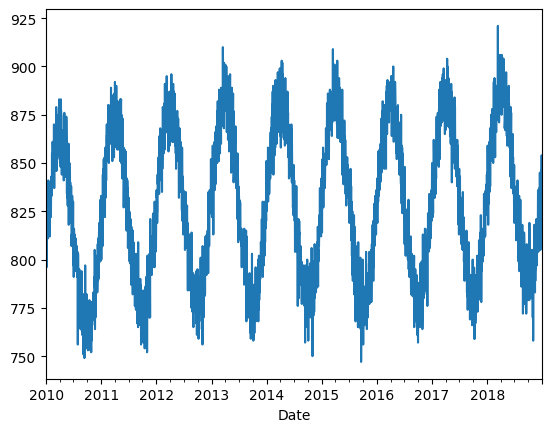

In [20]:
df_train[(df_train['store']==0)&(df_train['product']==0)]['number_sold'].plot()

In [21]:
train = df_train[(df_train['store']==0)&(df_train['product']==0)].drop(['store','product'], axis=1)
test = df_test[(df_test['store']==0)&(df_test['product']==0)].drop(['store','product'], axis=1)

Выберите также второй набор, с которым в дальнейшем будете выполнять манипуляции самостоятельно. Выберите интресный вариант.

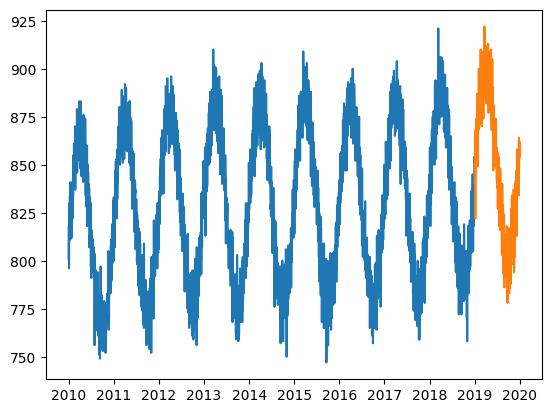

In [22]:
plt.plot(train)
plt.plot(test)

## Сглаживание

<Axes: xlabel='Date'>

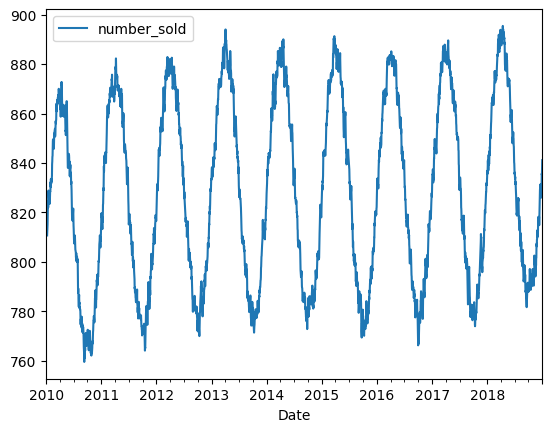

In [23]:
train.rolling(window=7).mean().plot()

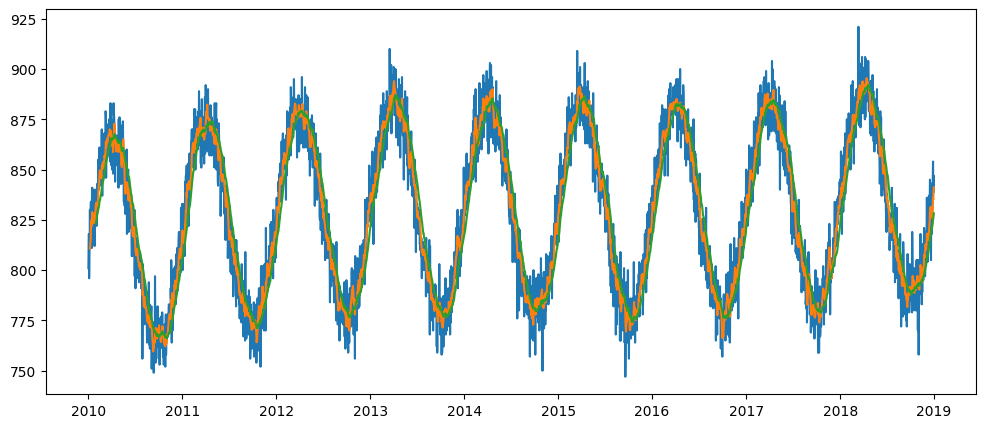

In [24]:
plt.figure(figsize=(12,5))
plt.plot(train)
plt.plot(train.rolling(window=7).mean())
plt.plot(train.rolling(window=30).mean())

<Axes: xlabel='Date'>

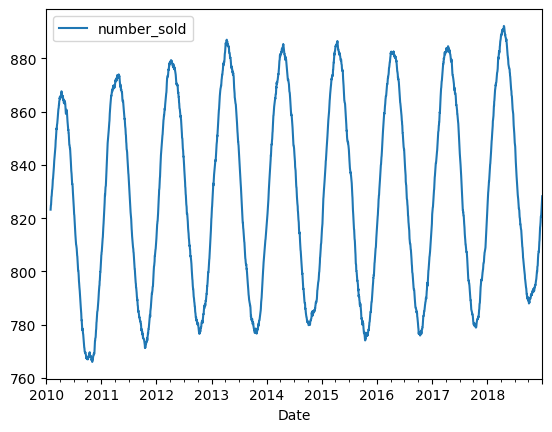

In [25]:
train.rolling(window=30).mean().plot()

<Axes: xlabel='Date'>

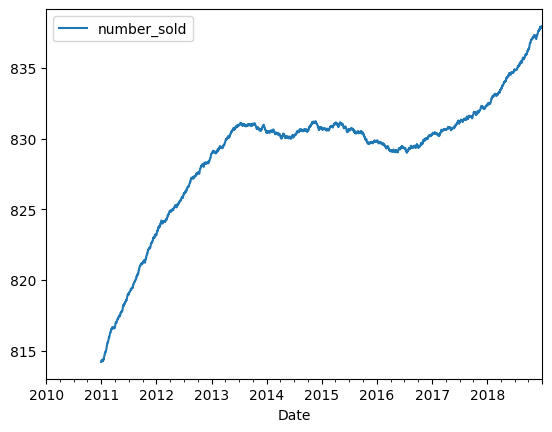

In [26]:
train.rolling(window=365).mean().plot()

## Сезонность

In [27]:
from statsmodels.tsa.seasonal import seasonal_decompose

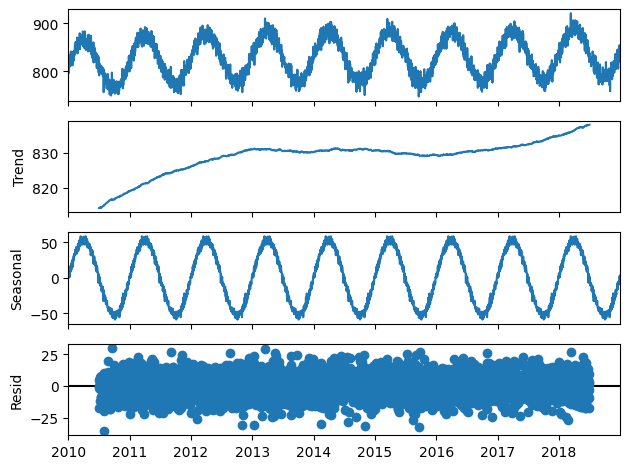

In [28]:
seasonal_decompose(train, model = 'additive', period = 365).plot()
plt.show()

## Лаги

In [29]:
train.head()

,number_sold
Date,
2010-01-01,801
2010-01-02,810
2010-01-03,818
2010-01-04,796
2010-01-05,808


In [30]:
train.shift(1).head()

,number_sold
Date,
2010-01-01,NaN
2010-01-02,801.0
2010-01-03,810.0
2010-01-04,818.0
2010-01-05,796.0


In [31]:
train.shift(-1).head()

,number_sold
Date,
2010-01-01,810.0
2010-01-02,818.0
2010-01-03,796.0
2010-01-04,808.0
2010-01-05,812.0


In [32]:
for i in range(1,7):
    string = f'lag{i}'
    train[string] = train['number_sold'].shift(i)
train.head(10)

,number_sold,lag1,lag2,lag3,lag4,lag5,lag6
Date,,,,,,,
2010-01-01,801,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-02,810,801.0,NaN,NaN,NaN,NaN,NaN
2010-01-03,818,810.0,801.0,NaN,NaN,NaN,NaN
2010-01-04,796,818.0,810.0,801.0,NaN,NaN,NaN
2010-01-05,808,796.0,818.0,810.0,801.0,NaN,NaN
2010-01-06,812,808.0,796.0,818.0,810.0,801.0,NaN
2010-01-07,830,812.0,808.0,796.0,818.0,810.0,801.0
2010-01-08,812,830.0,812.0,808.0,796.0,818.0,810.0
2010-01-09,817,812.0,830.0,812.0,808.0,796.0,818.0


<Axes: >

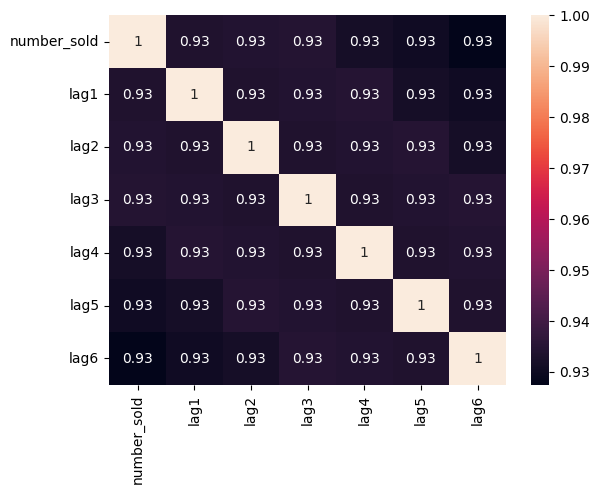

In [33]:
sns.heatmap(train.corr(), annot=True)

In [34]:
train.drop(list(train.columns[1:]), axis = 1, inplace = True)

<Axes: >

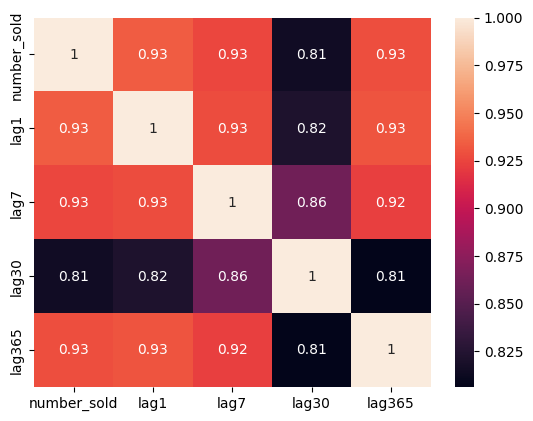

In [35]:
train['lag1'] = train['number_sold'].shift(1, axis = 0)
train['lag7'] = train['number_sold'].shift(7, axis = 0)
train['lag30'] = train['number_sold'].shift(30, axis = 0)
train['lag365'] = train['number_sold'].shift(365, axis = 0)

sns.heatmap(train.corr(), annot = True)

In [36]:
train.drop(list(train.columns[1:]), axis = 1, inplace = True)

In [37]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

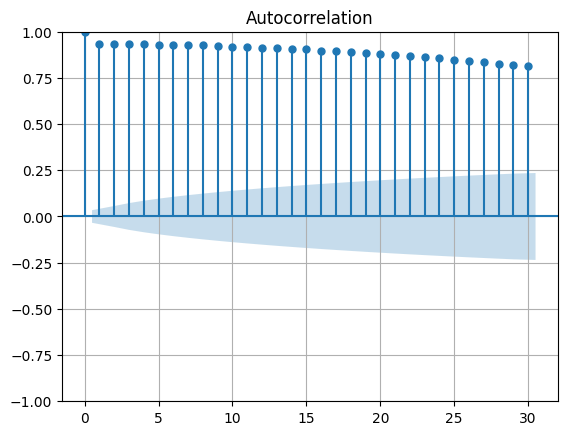

In [38]:
plot_acf(train, lags = 30)
plt.grid(True)
plt.show()

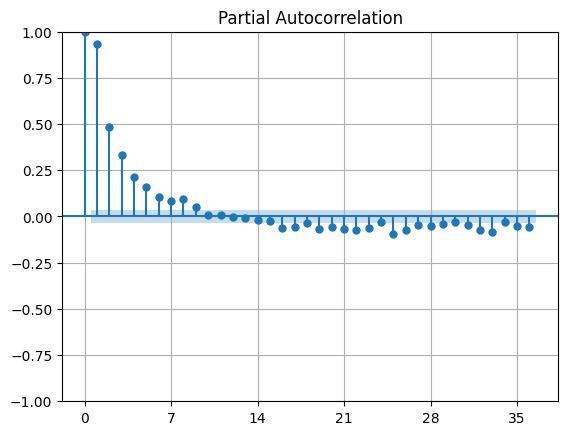

In [39]:
plot_pacf(train)
plt.xticks(range(0,40,7))
plt.grid(True)
plt.show()

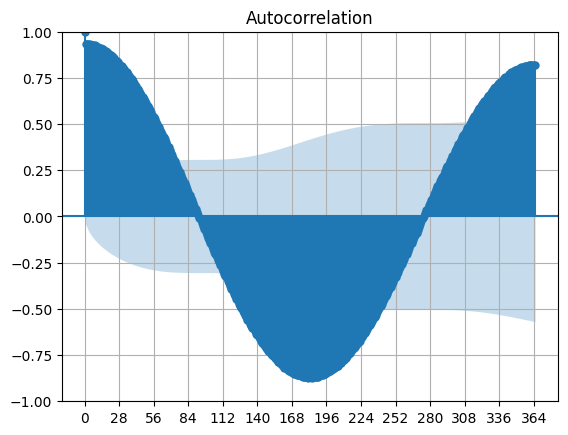

In [40]:
plot_acf(train, lags = 365)
plt.xticks(range(0,366, 28))

plt.grid(True)
plt.show()

## Прогнозирование

In [41]:
# !pip install skforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.3/467.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 26.5 MB/s eta 0:00:00


In [42]:
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import grid_search_forecaster
from skforecast.model_selection import backtesting_forecaster

from sklearn.linear_model import LinearRegression

In [43]:
train.asfreq('D')

,number_sold
Date,
2010-01-01,801
2010-01-02,810
2010-01-03,818
2010-01-04,796
2010-01-05,808
...,...
2018-12-27,847
2018-12-28,854
2018-12-29,839


In [44]:
forecaster = ForecasterRecursive(
    regressor = LinearRegression(),
    lags = 365)

forecaster.fit(train['number_sold'])
forecaster

TypeError: ForecasterRecursive.__init__() got an unexpected keyword argument 'regressor'

In [45]:
steps = len(test)

y_pred = forecaster.predict(steps = steps)
y_pred.head()

NameError: name 'forecaster' is not defined

In [ ]:
y_pred.index=test.index

In [ ]:
plt.plot(train)
plt.plot(test)
plt.plot(y_pred)